In [1]:
!pip install spacy --upgrade

In [2]:
!python -m spacy download en_core_web_sm

/home/michalek/miniconda3/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.1) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 5.0 MB/s  0:00:02a 0:00:010:00:01:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [3]:
import spacy
import en_core_web_sm
import pandas as pd
import seaborn as sns
import numpy as np
import re
import random

/home/michalek/miniconda3/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.1) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [4]:
train_data = pd.read_csv('data/train.csv', header = None,
                         names = ['sentiment', 'id', 'date', 'query', 'user', 'text'], encoding='latin1')

In [5]:
train_data

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
...,...,...,...,...,...,...
1599995,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


In [6]:
train_data['sentiment'].unique()

array([0, 4])

In [7]:
# sns.countplot(train_data['sentiment']);

In [8]:
np.unique(train_data['sentiment'], return_counts=True)

(array([0, 4]), array([800000, 800000]))

In [9]:
train_data = train_data.drop(['id', 'date', 'query', 'user'], axis=1)
train_data

,sentiment,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."
...,...,...
1599995,4,Just woke up. Having no school is the best fee...
1599996,4,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,Happy 38th Birthday to my boo of alll time!!! ...


## Train and test data

In [10]:
X = train_data.iloc[:, 1].values
X

array(["@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D",
       "is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!",
       '@Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds',
       ..., 'Are you ready for your MoJo Makeover? Ask me for details ',
       'Happy 38th Birthday to my boo of alll time!!! Tupac Amaru Shakur ',
       'happy #charitytuesday @theNSPCC @SparksCharity @SpeakingUpH4H '],
      dtype=object)

In [11]:
y = train_data.iloc[:, 0].values
y

array([0, 0, 0, ..., 4, 4, 4])

In [12]:
from sklearn.model_selection import train_test_split
X, _, y, _ = train_test_split(X, y, test_size = 0.97)

In [13]:
X

array(['Hey people   ',
       '@LoriMoreno Rt AnnetteDubow You go girl! Love You! Lori  - Thank you!x lol IAny locations you recommend? Or ref auditioning for the show?',
       "@ijustine yup! Your videos aren't working for me either ", ...,
       'Home  Whoa im watchin Law &amp; Order SVU new episode . . . . . . . . . . . Wit moms ',
       '500th Tweet!! Looking forward to the next 500 tweets to royally piss all of you off! ',
       '@iMonic Bye Mon! I will. I LOV you 2! '], dtype=object)

In [14]:
X.shape

(48000,)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [16]:
X_train.shape, y_train.shape

((38400,), (38400,))

In [17]:
X_test.shape, y_test.shape

((9600,), (9600,))

In [18]:
np.unique(y_train, return_counts=True)

(array([0, 4]), array([19212, 19188]))

In [19]:
np.unique(y_test, return_counts=True)

(array([0, 4]), array([4836, 4764]))

# Preprocessing the data

In [20]:
nlp = spacy.load('en_core_web_sm')
nlp

In [21]:
def preprocessing(sentence):
  sentence = sentence.lower()
  sentence = re.sub(r"@[A-Za-z0-9]+", ' ', sentence)
  sentence = re.sub(r"https?://[A-Za-z0-9./]+", ' ', sentence)
  sentence = sentence.replace('.', '')
  tokens = []
  tokens = [token.text for token in nlp(sentence) if not (token.is_stop or token.like_num or token.is_punct or token.is_space or len(token) == 1)]
  tokens = ' '.join([element for element in tokens])

  return tokens

In [22]:
preprocessing("@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  2 You shoulda got David Carr of Third Day to do it. ;D")

'awww bummer shoulda got david carr day'

In [23]:
X_train_cleaned = [preprocessing(tweet) for tweet in X_train]

In [24]:
len(X_train_cleaned)

38400

In [25]:
for _ in range(10):
  print(X_train_cleaned[random.randint(0, len(X_train_cleaned) - 1)])

watch 3dfeel like dork glasses
rose_xoxo kno right pull miss florida
sold fun
private soror bachelorette party stripper omgthis nite gon na crazy hope twitcrazy twitpics allowed
setting wedding pretty
soooooo bored unreal
lt;3 em album left disappointed mtvmovieawards
watched angels demons itâ´s good movie didinâ´t loved mutilated book changed things
wanna prepare work time
majorly wrong camera cool warranty anymore man


In [26]:
X_test_cleaned = [preprocessing(tweet) for tweet in X_test]

## Word cloud

In [27]:
texts = ''
for text in X_train_cleaned:
  texts += ' ' + text

In [28]:
texts

" wish knew better know happening help hugs qa nt congratulate followers twitter pretty dissapointing day aerobics teacher cry thought essay amazing wants yesssss guided tour 3gs awesome year contract work busy going leave place thanks tweets support cut pescetarian rubbish tweepsthanks follow sorry babe hope fix is_here good morning bitch mama iz today twitter profile picture god stuffed china china soooooo fillingg geography sick getting better nice fml kinda want crawl corner head fighting lucky germany univercity lt;3 thank send pics aim fucks seesmic updating properly milano thought regard quot;oops busted shhh bye&quot getting addicted twitter ha ha ha bank omg purple car big shut welcome aboard girl click strong people brutal brutal brutal media=1164 sleepy wants home rest rest palawan trip hungry calculus exam flights booked plus ggd2 birthday miss especially missed ggd1 coolllddddd hopefully cold tonight wear cool winter jackets city2surf trainning day km 60mins min walking wa

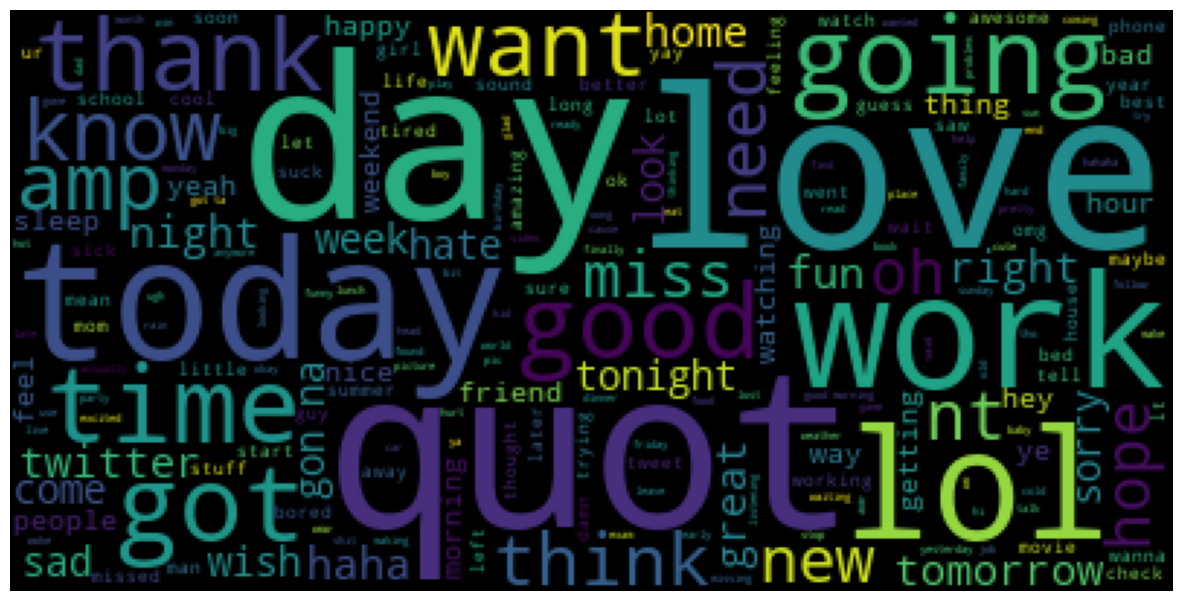

In [29]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
cloud = WordCloud()
cloud = cloud.generate(texts)
plt.figure(figsize=(15,15))
plt.imshow(cloud)
plt.axis('off');

# Detecting languages

In [30]:
!pip install langdetect

In [31]:
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException

In [32]:
detect('This is an English text')

'en'

In [33]:
detect('Este é um texto em português')

'pt'

In [34]:
detect('Este es un texto en espanõl')

'es'

In [35]:
languages = []
for text in X_test_cleaned:
    if text != '':
        try:
            languages.append(detect(text))
        except LangDetectException:
            languages.append('unknown')  # Or 'und' for undetermined
    else:
        languages.append('unknown')

In [36]:
np.unique(languages, return_counts=True)

(array(['af', 'ca', 'cs', 'cy', 'da', 'de', 'en', 'es', 'et', 'fi', 'fr',
        'hr', 'hu', 'id', 'it', 'lt', 'lv', 'nl', 'no', 'pl', 'pt', 'ro',
        'sk', 'sl', 'so', 'sq', 'sv', 'sw', 'tl', 'tr', 'unknown', 'vi'],
       dtype='<U7'),
 array([ 571,   41,   17,  152,  135,   36, 6807,   55,  121,   63,  163,
          29,   12,   95,   99,    6,    7,  174,  162,   41,   27,   61,
          22,   25,  291,   19,   59,   45,  160,   24,   65,   16]))

# Sentiment analysis with NLTK

In [37]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/michalek/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [38]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [39]:
nltk_classifier = SentimentIntensityAnalyzer()
nltk_classifier.polarity_scores('I love this food')

{'neg': 0.0, 'neu': 0.323, 'pos': 0.677, 'compound': 0.6369}

In [40]:
nltk_classifier.polarity_scores('I hate this food')

{'neg': 0.649, 'neu': 0.351, 'pos': 0.0, 'compound': -0.5719}

In [41]:
nltk_classifier.polarity_scores('I have this food')

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

In [42]:
X_train_cleaned[0]

'wish knew better know happening help hugs'

In [43]:
nltk_classifier.polarity_scores(X_train_cleaned[0])

{'neg': 0.0, 'neu': 0.207, 'pos': 0.793, 'compound': 0.8885}

In [44]:
X_train_cleaned[20002]

'scrubs wanna watch eps twin peaks think series finales day'

In [45]:
nltk_classifier.polarity_scores(X_train_cleaned[20002])

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

In [46]:
for sentence in X_test:
  print(nltk_classifier.polarity_scores(sentence), ' - ', sentence)

{'neg': 0.0, 'neu': 0.795, 'pos': 0.205, 'compound': 0.6588}  -  It's my last day of my (mini) vacation, had a great time. I'm going back to work tomorrow. Boo! 
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  in Uni.... again! 
{'neg': 0.0, 'neu': 0.532, 'pos': 0.468, 'compound': 0.8904}  -  has woken up and is enjoying some sarah(my sister) free time on this fun saturday 
{'neg': 0.096, 'neu': 0.797, 'pos': 0.108, 'compound': 0.0772}  -  oh, anyone in the Seattle area who is interested in the previous shoe I posted in my previous post just shoot me a DM 
{'neg': 0.055, 'neu': 0.629, 'pos': 0.317, 'compound': 0.7393}  -  @froren  Sorry! You are being freed tomorrow? Want some good suggestions for food, or have you already discovered localnoodles.com ?
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  you have to watch it 
{'neg': 0.275, 'neu': 0.44, 'pos': 0.286, 'compound': 0.0258}  -  needs to clear up the mess 
{'neg': 0.0, 'neu': 0.667, 'pos': 0.333, 'compound': 

{'neg': 0.0, 'neu': 0.583, 'pos': 0.417, 'compound': 0.6133}  -  @AlexAllTimeLow don't be nervous, it's a really good clip anyways 
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  juicystar007 kicked me out of blogtv cuz i really wanted her to call me. 
{'neg': 0.0, 'neu': 0.673, 'pos': 0.327, 'compound': 0.528}  -  tom. is my dad's birthday! I'm so excited 
{'neg': 0.089, 'neu': 0.766, 'pos': 0.145, 'compound': 0.3382}  -  @Dan_Savage Cant watch the Game tonight...  Will be @the game Sunday night tho..1st game I have missed in a long long while...Have fun!
{'neg': 0.274, 'neu': 0.66, 'pos': 0.066, 'compound': -0.6234}  -  #haveyouever Met someone from MySpace? Want to? http://www.MySpaceToMyPlace.com  (Yeah I know thats a shameless, corny plug...I dont care 
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  @Whoknows1970 bye 
{'neg': 0.0, 'neu': 0.569, 'pos': 0.431, 'compound': 0.6486}  -  so , i've just finished dinner... yummy ;)   Lomo saltado  
{'neg': 0.0, 'neu'

{'neg': 0.194, 'neu': 0.806, 'pos': 0.0, 'compound': -0.5859}  -  i just got home from flavius's graduation and i dominate at volleyball and ping pong have been out since ten, and its eleven...still sick 
{'neg': 0.333, 'neu': 0.667, 'pos': 0.0, 'compound': -0.3595}  -  @ijustine Sometimes you have no choice! 
{'neg': 0.0, 'neu': 0.69, 'pos': 0.31, 'compound': 0.2023}  -  [on] playing restaurant city again 
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  goin to see chito! for a little bit! 
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  @marcfonteijn check you mail 
{'neg': 0.0, 'neu': 0.563, 'pos': 0.437, 'compound': 0.4767}  -  going to my friends house 
{'neg': 0.479, 'neu': 0.388, 'pos': 0.134, 'compound': -0.8405}  -  Silence! I'll Kill U!!! - hard day... Can somebody relief my mind from pain??? 
{'neg': 0.0, 'neu': 0.729, 'pos': 0.271, 'compound': 0.6239}  -  @LouisPagan wow that response made my head spin.  too early for that! 
{'neg': 0.256, 'neu': 0.744, 

{'neg': 0.0, 'neu': 0.497, 'pos': 0.503, 'compound': 0.8786}  -  at naomi's  had fun last night :-D it's beginning to feel like summer! 
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  had to much to eat today. Now time to go work it off 
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  On my way to LA 2 The Roxy. Carmen Electra will b there and I WILL get a picture. Its my mission! 
{'neg': 0.208, 'neu': 0.792, 'pos': 0.0, 'compound': -0.6124}  -  getting home at 4am from the longest day at work sucks but being back for a meeting at 8am sucks even more 
{'neg': 0.164, 'neu': 0.597, 'pos': 0.238, 'compound': 0.2481}  -  @faithfulmusic  Oh No girl~! I hope you can get another  flight 
{'neg': 0.0, 'neu': 0.801, 'pos': 0.199, 'compound': 0.3054}  -  @SmellyluvMJ thanks for the information! but it says coming soon... 
{'neg': 0.331, 'neu': 0.669, 'pos': 0.0, 'compound': -0.872}  -  @JoeGarde Ah what can u do? Insult is being added to injury by twitter rumblings of BBQ f

{'neg': 0.0, 'neu': 0.743, 'pos': 0.257, 'compound': 0.6696}  -  @AubreyODay I love you so much! and I'm gonna keep twittering until I get a reply.. lalala 
{'neg': 0.0, 'neu': 0.762, 'pos': 0.238, 'compound': 0.6892}  -  @nerdist Awesome! Let us know what you think of the Ubisoft media! Mainly the opening sizzle 
{'neg': 0.0, 'neu': 0.818, 'pos': 0.182, 'compound': 0.4389}  -  @tommcfly love your glasses! are they wayfarers? I had a few pairs but had to sell 
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  I think i will be a programmer  Don`t know
{'neg': 0.0, 'neu': 0.834, 'pos': 0.166, 'compound': 0.5242}  -  Lets go CAVs.  faith is all we need! at the end of the day its up to YALL!
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  watchinq Seven Pounds ; is this movie qood ? I quess I jusst have to find out &amp; see 
{'neg': 0.193, 'neu': 0.807, 'pos': 0.0, 'compound': -0.4767}  -  @3sixty5days http://twitpic.com/6cpls - itsnot underage its 18 over here  but 21 

{'neg': 0.18, 'neu': 0.738, 'pos': 0.082, 'compound': -0.4641}  -  @myopicjoe if it were baby C I'd be even more upset. C's fair &amp; T got darker skin genes. Even so his back is red &amp; hurting him 
{'neg': 0.0, 'neu': 0.588, 'pos': 0.412, 'compound': 0.4215}  -  lol got me a big brother 
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  EnglÃ¬sh  exam today 
{'neg': 0.333, 'neu': 0.667, 'pos': 0.0, 'compound': -0.3612}  -  @day_b still fighting the time change. 
{'neg': 0.099, 'neu': 0.752, 'pos': 0.149, 'compound': 0.3094}  -  @kira5472 I swag when I surf lol ATL huh??? That's wass up....its pouring down here sucks  what do you have going for today???
{'neg': 0.0, 'neu': 0.646, 'pos': 0.354, 'compound': 0.8555}  -  @danieldraper @oliyoung you produce it and I'll do what I can to help promote it  I'm always looking for good customer stories to share
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  met Emeril twice 
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  @SLVHealthDept Did that work then? It's been doing that to me every time I open it since the &quot;upgrade&quot;. 
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  off to pick up dannielle 
{'neg': 0.0, 'neu': 0.556, 'pos': 0.444, 'compound': 0.4939}  -  Trying to save my hair 
{'neg': 0.0, 'neu': 0.815, 'pos': 0.185, 'compound': 0.5267}  -  3/4 finished with type-in. When I finish, I'm rewarding myself with a little @peterfacinelli, @billy_burke, and @gilbirmingham action. 
{'neg': 0.141, 'neu': 0.654, 'pos': 0.205, 'compound': 0.2168}  -  @fixhoo Well...u must be good in something special, u know? Are u in college and stuff? Cuz otherwise, u may get the worst jobs ever 
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  Up early on Saturday  off to work... Bring on the sunshine!!!!!!!
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  @butterfly716 I am 
{'neg': 0.454, 'neu': 0.546, 'pos': 0.0, 'compound

{'neg': 0.1, 'neu': 0.753, 'pos': 0.146, 'compound': -0.238}  -  @chanelleannexox lol i dont ! and omfg ! nevershoutnever is playing july 15th in tdot  but you dont like him so who am i gonna go with? 
{'neg': 0.0, 'neu': 0.802, 'pos': 0.198, 'compound': 0.5719}  -  @tintin85 you could have invited some twitter folk from chennai too you know. happy bday btw 
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  #zzz. tchow 
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}  -  @taffylaughy not  i iwhs!
{'neg': 0.304, 'neu': 0.435, 'pos': 0.261, 'compound': -0.128}  -  I'm cursed.  i have bad luck with cars 
{'neg': 0.0, 'neu': 0.882, 'pos': 0.118, 'compound': 0.4215}  -  @Fairywispa I've just checked on the internet and the house I liked is now &quot;let pending&quot;  Obviously it was not meant to be....
{'neg': 0.0, 'neu': 0.289, 'pos': 0.711, 'compound': 0.9406}  -  @peterfacinelli congrats on winning BEST MOVIE at the movie awards 
{'neg': 0.386, 'neu': 0.614, 'pos': 0.0, '

# Sentiment analysis with TF-IDF

In [47]:
X_train_cleaned[0:5]

['wish knew better know happening help hugs',
 'qa nt congratulate',
 'followers twitter',
 'pretty dissapointing day aerobics teacher cry thought essay amazing wants',
 'yesssss guided tour 3gs awesome year contract']

In [48]:
y_train

array([0, 0, 4, ..., 4, 0, 0])

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train_cleaned)

In [50]:
X_train_tfidf.toarray().shape

(38400, 33365)

In [51]:
len(vectorizer.get_feature_names_out())

33365

In [52]:
def preprocessing_lemma(sentence):
  tokens = []
  tokens = [token.lemma_ for token in nlp(sentence)]
  tokens = ' '.join([element for element in tokens])
  return tokens 

In [53]:
preprocessing_lemma('learn learned learning')

'learn learn learning'

In [54]:
X_train_cleaned_lemma = [preprocessing_lemma(tweet) for tweet in X_train_cleaned]

In [55]:
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train_cleaned_lemma)

In [56]:
X_train_tfidf.shape

(38400, 29996)

In [57]:
X_test_cleaned_lemma = [preprocessing_lemma(tweet) for tweet in X_test_cleaned]

In [58]:
X_test_tfidf = vectorizer.transform(X_test_cleaned_lemma)

In [59]:
X_test_tfidf.shape

(9600, 29996)

In [60]:
from sklearn.tree import DecisionTreeClassifier

In [61]:
classifier = DecisionTreeClassifier()
classifier.fit(X_train_tfidf, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [62]:
predictions = classifier.predict(X_test_tfidf)

In [63]:
predictions

array([0, 4, 4, ..., 4, 4, 0])

In [64]:
y_test

array([0, 0, 4, ..., 0, 4, 0])

In [65]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [66]:
accuracy_score(y_test, predictions)

0.6811458333333333

In [67]:
cm = confusion_matrix(y_test, predictions)
cm

array([[3234, 1602],
       [1459, 3305]])

In [71]:
(3234 + 3305) / 9600

0.6811458333333333

In [72]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.69      0.67      0.68      4836
           4       0.67      0.69      0.68      4764

    accuracy                           0.68      9600
   macro avg       0.68      0.68      0.68      9600
weighted avg       0.68      0.68      0.68      9600



# Sentiment analysis with spaCy

In [73]:
example = [["this is a positive text", {"POSITIVE": True, "NEGATIVE": False}],
           ["this is a negative text", {"POSITIVE": False, "NEGATIVE": True}]]

In [74]:
X_train_spacy = []
for text, sentiment in zip(X_train_cleaned_lemma, y_train):
  #print(text, sentiment)
  if sentiment == 4:
    dic = ({'POSITIVE': True, 'NEGATIVE': False})
  elif sentiment == 0:
    dic = ({'POSITIVE': False, 'NEGATIVE': True})
  X_train_spacy.append([text, dic.copy()])

In [75]:
X_train_spacy[0:5]

[['wish know well know happen help hug',
  {'POSITIVE': False, 'NEGATIVE': True}],
 ['qa not congratulate', {'POSITIVE': False, 'NEGATIVE': True}],
 ['follower twitter', {'POSITIVE': True, 'NEGATIVE': False}],
 ['pretty dissapointing day aerobics teacher cry think essay amazing want',
  {'POSITIVE': True, 'NEGATIVE': False}],
 ['yesssss guide tour 3gs awesome year contract',
  {'POSITIVE': False, 'NEGATIVE': True}]]

In [76]:
nlp.pipe_names

['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']

In [77]:
classifier_spacy = spacy.blank('en')
classifier_spacy.pipe_names

[]

In [78]:
textcat = classifier_spacy.add_pipe('textcat')
classifier_spacy.pipe_names

['textcat']

In [79]:
textcat.add_label('POSITIVE')
textcat.add_label('NEGATIVE')

1

In [80]:
textcat.label_data

('POSITIVE', 'NEGATIVE')

In [81]:
len(X_train_spacy)

38400

In [82]:
38400 / 1024

37.5

In [83]:
from spacy.training import Example
classifier_spacy.begin_training()
for epoch in range(10):
  random.shuffle(X_train_spacy)
  losses = {}
  for batch in spacy.util.minibatch(X_train_spacy, 1024):
    texts = [classifier_spacy.make_doc(text) for text, entities in batch]
    annotations = [{'cats': entities} for text, entities in batch]
    examples = [Example.from_dict(doc, annotation) for doc, annotation in zip(texts, annotations)]
    classifier_spacy.update(examples, losses=losses)
  print(losses)

{'textcat': 7.974378347396851}
{'textcat': 5.902150794863701}
{'textcat': 4.407155342400074}
{'textcat': 2.9225738495588303}
{'textcat': 1.768417239189148}
{'textcat': 1.107377509586513}
{'textcat': 0.8534771669656038}
{'textcat': 0.6867866516113281}
{'textcat': 0.6491427291184664}
{'textcat': 0.571212159935385}


In [84]:
classifier_spacy.to_disk('classifier_spacy')

In [85]:
classifier_spacy_loaded = spacy.load('classifier_spacy')
classifier_spacy_loaded

In [86]:
y_test[4863]

np.int64(4)

In [87]:
positive_text = X_test_cleaned_lemma[4863]
positive_text

'stoke life'

In [88]:
prediction = classifier_spacy_loaded(positive_text)
prediction

stoke life

In [89]:
prediction.cats

{'POSITIVE': 0.999799907207489, 'NEGATIVE': 0.00020014472829643637}

In [90]:
classifier_spacy_loaded('i love this food').cats

{'POSITIVE': 0.13817256689071655, 'NEGATIVE': 0.8618274927139282}

In [91]:
y_test[4712]

np.int64(4)

In [92]:
negative_text = X_test_cleaned_lemma[4712]
negative_text

'true true writing atm try coherent yrs&amp;string narrative meat rot nicely'

In [93]:
prediction = classifier_spacy_loaded(negative_text)
prediction.cats

{'POSITIVE': 0.9966829419136047, 'NEGATIVE': 0.0033170050010085106}

In [94]:
classifier_spacy_loaded('i hate this food').cats

{'POSITIVE': 8.21562935016118e-05, 'NEGATIVE': 0.9999178647994995}

In [95]:
predictions = []
for text in X_test_cleaned_lemma:
  prediction = classifier_spacy_loaded(text)
  predictions.append(prediction.cats)

In [96]:
predictions

[{'POSITIVE': 0.001418294501490891, 'NEGATIVE': 0.9985817670822144},
 {'POSITIVE': 0.9701509475708008, 'NEGATIVE': 0.029849085956811905},
 {'POSITIVE': 0.9948509335517883, 'NEGATIVE': 0.005149020813405514},
 {'POSITIVE': 0.1131344586610794, 'NEGATIVE': 0.886865496635437},
 {'POSITIVE': 0.0049096038565039635, 'NEGATIVE': 0.9950903654098511},
 {'POSITIVE': 0.9871368408203125, 'NEGATIVE': 0.012863141484558582},
 {'POSITIVE': 0.1789463460445404, 'NEGATIVE': 0.8210536241531372},
 {'POSITIVE': 0.9846217632293701, 'NEGATIVE': 0.015378260985016823},
 {'POSITIVE': 0.006795709021389484, 'NEGATIVE': 0.9932042360305786},
 {'POSITIVE': 0.34908467531204224, 'NEGATIVE': 0.6509153842926025},
 {'POSITIVE': 0.031312450766563416, 'NEGATIVE': 0.9686874747276306},
 {'POSITIVE': 0.9366425275802612, 'NEGATIVE': 0.06335751712322235},
 {'POSITIVE': 0.9953384399414062, 'NEGATIVE': 0.0046615260653197765},
 {'POSITIVE': 0.9999881982803345, 'NEGATIVE': 1.1812120646936819e-05},
 {'POSITIVE': 0.9999676942825317, 'NE

In [97]:
predictions2 = []
for prediction in predictions:
  if prediction['POSITIVE'] > prediction['NEGATIVE']:
    predictions2.append(4)
  else:
    predictions2.append(0)
predictions2 = np.array(predictions2)

In [98]:
predictions2

array([0, 4, 4, ..., 0, 0, 4])

In [99]:
y_test

array([0, 0, 4, ..., 0, 4, 0])

In [100]:
accuracy_score(y_test, predictions2)

0.69

In [101]:
cm = confusion_matrix(y_test, predictions2)
cm

array([[3491, 1345],
       [1631, 3133]])

In [102]:
print(classification_report(y_test, predictions2))

              precision    recall  f1-score   support

           0       0.68      0.72      0.70      4836
           4       0.70      0.66      0.68      4764

    accuracy                           0.69      9600
   macro avg       0.69      0.69      0.69      9600
weighted avg       0.69      0.69      0.69      9600

